# densmix

<!-- badges: start -->
<!-- badges: end -->

Here we show several examples for densmix library related to multinomial density separation.

## Generate data and fit mixtures

We start by generating many datasets with fixed parameters and then using the library to decompose it.

We fix number of components to be equal to $3$ and weights of components to be equal to $c(0.1,0.2,0.7)$.

We generate component profiles from uniform Dirichlet distribution and then try to find them.

Number of buckets *n_buckets* mean that dataset will have 12 columns.

Parameters *max_actions* and *prob_action* control how we fill in such dataset:

Each multinomial component is described

- Vector of probabilities we take from Dirichlet
- "Total number of objects" that "distributed" across 12 buckets. That "total number of objects" is generated once per component as one value from binomial distribution with (a) number of trials equal to *max_actions* and (b) probability of success equal to *prob_action*.

You can think about dataset generatio as two step process:

- Step 1. Define Multinomial: Generate vector of probabilities from uniform Dirichlet, generate total number of observations from binomial.
- Step 2. Given fully defined multinomial component, generate $w[k]*N$ samples, where $w[k]$ is the weight of $k$th component and $N$ is required sample size (defined by $size$).


In [1]:
import numpy as np
import pandas as pd
from densmix.generator import Generator
from densmix.models import Models
import matplotlib.pyplot as plt

In [5]:
np.random.seed(1234)

n_sim = 100

multinomial_parameters = {
    "n_components": 3,
    "n_buckets": 12,
    "dirichlet": np.ones(12),
    "component_weights": np.array([0.1, 0.2, 0.7]),
    "n_actions_per_bucket": {
        "max_actions": 100,
        "prob_action": 0.5
    }
}

em_nm_gen_list = [
    Generator(
        size=1000,
        parameters=multinomial_parameters
    ).gen_multinom()
    for _ in range(n_sim)
]

em_nm_fit_list = [
    Models(generated_data["data"]).fit_multinom( n_components=3)
    for generated_data in em_nm_gen_list
]

# Label comparison

Next, we compare labels:

- Generator gives us true lables
- We extract predicted labels as "argmax" from table with posterior Bayesian probabilities (that table is part of the EM-algorithm).

Finally, as EM returns arbitrary labels, we use Hungarian algoritm to find "best" permutation of labels in the fit to match true labels.

In [6]:
from scipy.optimize import linear_sum_assignment

em_mn_fit_labels_list = [
    np.argmax(fit["bayes_probs"], axis=1)
    for fit in em_nm_fit_list
]

em_mn_true_labels_list = [
    generated["component_labels"]
    for generated in em_nm_gen_list
]


def get_accuracy_and_weights(true_labels, fitted_labels, fit):
    n_components = fit["bayes_probs"].shape[1]

    confusion_table = np.zeros(
        (n_components, n_components),
        dtype=int
    )

    np.add.at(
        confusion_table,
        (true_labels, fitted_labels),
        1
    )

    row_indices, fitted_permutation = linear_sum_assignment(
        confusion_table,
        maximize=True
    )

    accuracy = (
        np.sum(confusion_table[row_indices, fitted_permutation])
        / np.sum(confusion_table)
    )

    aligned_weights = fit["weights"][fitted_permutation]

    return {
        "accuracy": accuracy,
        "weights": aligned_weights
    }


em_mn_acc_weights_list = [
    get_accuracy_and_weights(
        true_labels,
        fitted_labels,
        fit
    )
    for true_labels, fitted_labels, fit in zip(
        em_mn_true_labels_list,
        em_mn_fit_labels_list,
        em_nm_fit_list
    )
]

accuracy = np.array([
    result["accuracy"]
    for result in em_mn_acc_weights_list
])

# Comparison

Finally, we compare labels by checking accuracy of the fit.

Accuracy is quite high (in most of the cases it is 100%).

Reasons are:

- We have only 3 components, which is easy to decompose
- Average total number of observations per row in the original dataset is 50 (controlled by max_actions*prob_action = 50

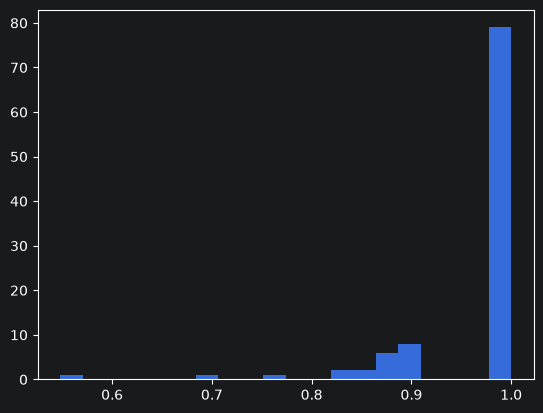

In [7]:
plt.hist(accuracy, bins=20)
plt.show()

# Weights
We also check weights of the components that were fixed at $c(0.1,0.2,0.7)$:

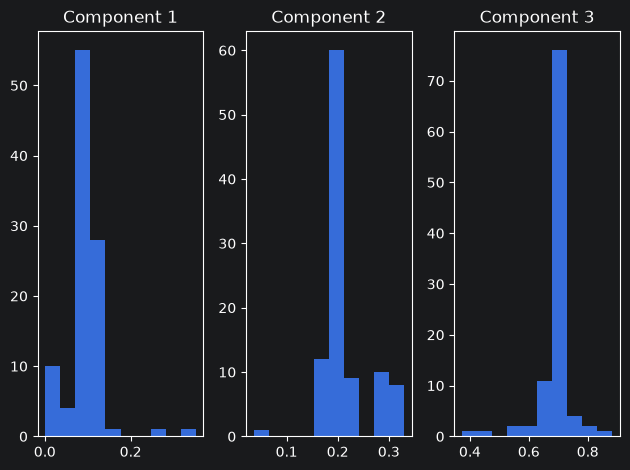

In [9]:
weights = np.vstack([
    result["weights"]
    for result in em_mn_acc_weights_list
])

fig, axes = plt.subplots(1, 3)

for j, ax in enumerate(axes):
    ax.hist(weights[:, j])
    ax.set_title(f"Component {j + 1}")

plt.tight_layout()
plt.show()

# Iterations

We also check how in many iterations algorithm converges:

to see that it usually converges fast (around 75% of cases in under 20 iterations).

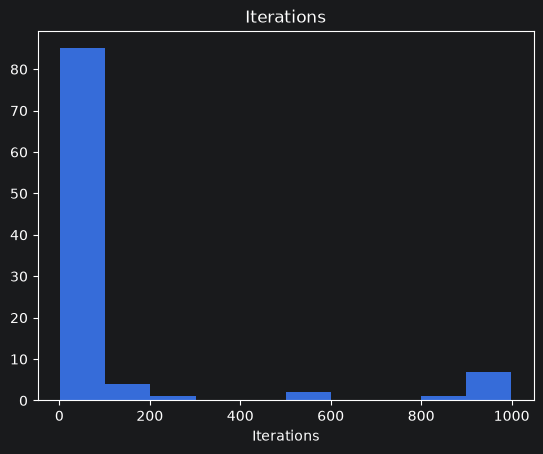

array([  2. ,   4. ,   5. ,  12.5, 999. ])

In [10]:
iteration_vector = np.array([
    fit["iterations"]
    for fit in em_nm_fit_list
])

plt.hist(iteration_vector)
plt.title("Iterations")
plt.xlabel("Iterations")
plt.show()

np.quantile(
    iteration_vector,
    [0, 0.25, 0.5, 0.75, 1]
)